<a href="https://colab.research.google.com/github/NITHYASHREE-N-RAJ/computer-vision/blob/main/cumputer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
#main library for computer vision we nead it to read image, detect faces and draw rectangle
!pip install opencv-python matplotlib --quiet

In [72]:
import cv2
from matplotlib import pyplot as plt
from google.colab import files

#cv2->all computer vision function
#matplotlib.pyplot-> display image in notebook
#files-.to upload image from computer in colab

In [73]:
image_file='/content/two.avif' #colab path
image=cv2.imread(image_file)

#file.upload() opens a file picker to select image from pc
#uploaded.keys() gives name you just upload

In [74]:
image = cv2.imread(image_file)
image_rgb=cv2.cvtColor(image,cv2.COLOR_BGR2RGB) #conver for proper display

#cv2.imread()->reads the image as an array (opencv works with array)
#opencv reads the RGB formate by default. but matplotlib user rgb format so we convert it

In [75]:
!wget -O haar_face.xml https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml
face_cascade=cv2.CascadeClassifier('haar_face.xml')

#wget->command line tool to download file from the internet
#-O haa_face.xml->save the download file locally with name haar_face.xml
#the url->points to opencv's pre-trained haar cascade file from frontal face detection
# haar cascade -> pre-trained model to detect the face
#cascadeclassifier() loads the mode so we can use it

--2026-03-13 06:41:18--  https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 930127 (908K) [text/plain]
Saving to: ‘haar_face.xml’

haar_face.xml       100%[===================>] 908.33K  --.-KB/s    in 0.05s   

2026-03-13 06:41:18 (17.7 MB/s) - ‘haar_face.xml’ saved [930127/930127]



In [76]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#face detection work faster and better on grayscale image
#no need to check 3 color channels (RGB) for detection

In [77]:
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=10)
#detectMultiScale() -> scans image to find faces
#scaleFactor=1.1 ->image scale changes slightly each step
#minNighbours=5 ->minimum rectangle to conform a face

In [78]:
for(x,y,w,h) in faces:
  cv2.rectangle(image_rgb,(x,y),(x+w,y+h),(255,0,0),2)
  #(x,y,w,h)-> coordinates of detected face
  #cv2.rectangle()-> draws a rectangle on the image
  #(255,0,0) -> blue rectangle in RGB (matplotlib expects RGB)
  #2 -> thickness of the rectangle

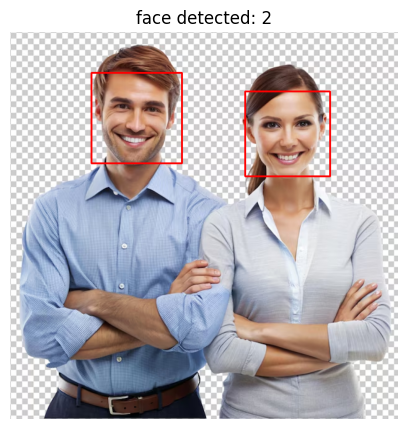

In [79]:
plt.figure(figsize=(5,6))
plt.imshow(image_rgb)
plt.title(f'face detected: {len(faces)}')
plt.axis('off')
plt.show()